# W1D5: Data Visualisation with Matplotlib and Seaborn

This notebook reuses the cleaned W1D4 student data and creates reproducible charts with Matplotlib and Seaborn. The deterministic workflow is suitable for an MLOps baseline: chart artifacts can be versioned alongside the data-preparation code before model experiments are tracked.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

repository_root = Path.cwd().resolve()
if not (repository_root / 'src').exists():
    repository_root = repository_root.parent
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

from src.w1d5_visualization import build_student_dataframe, create_visualizations

In [2]:
df = build_student_dataframe()
display(df.head())
print('Rows:', len(df))
print('Missing score values after W1D4 imputation:', df[['math', 'python', 'ml_score', 'avg_score']].isna().sum().sum())
display(df[['math', 'python', 'ml_score', 'avg_score']].describe().round(2))

,student_id,name,age,math,python,ml_score,attended,avg_score,grade
0,1,Student_1,23,70,62,89.0,True,73.7,C
1,2,Student_2,24,82,48,79.0,True,69.7,C
2,3,Student_3,22,61,69,43.0,True,57.7,F
3,4,Student_4,24,71,58,73.0,True,67.3,C
4,5,Student_5,24,93,94,45.0,True,77.3,B


Rows: 20
Missing score values after W1D4 imputation: 0


,math,python,ml_score,avg_score
count,20.00,20.00,20.00,20.00
mean,76.05,69.20,71.35,72.21
std,14.25,16.52,14.87,7.95
min,52.00,46.00,43.00,57.70
25%,64.75,56.75,63.00,66.97
50%,75.00,66.50,73.00,73.30
75%,88.75,82.00,81.50,76.85
max,98.00,97.00,93.00,84.70


score_distributions.png


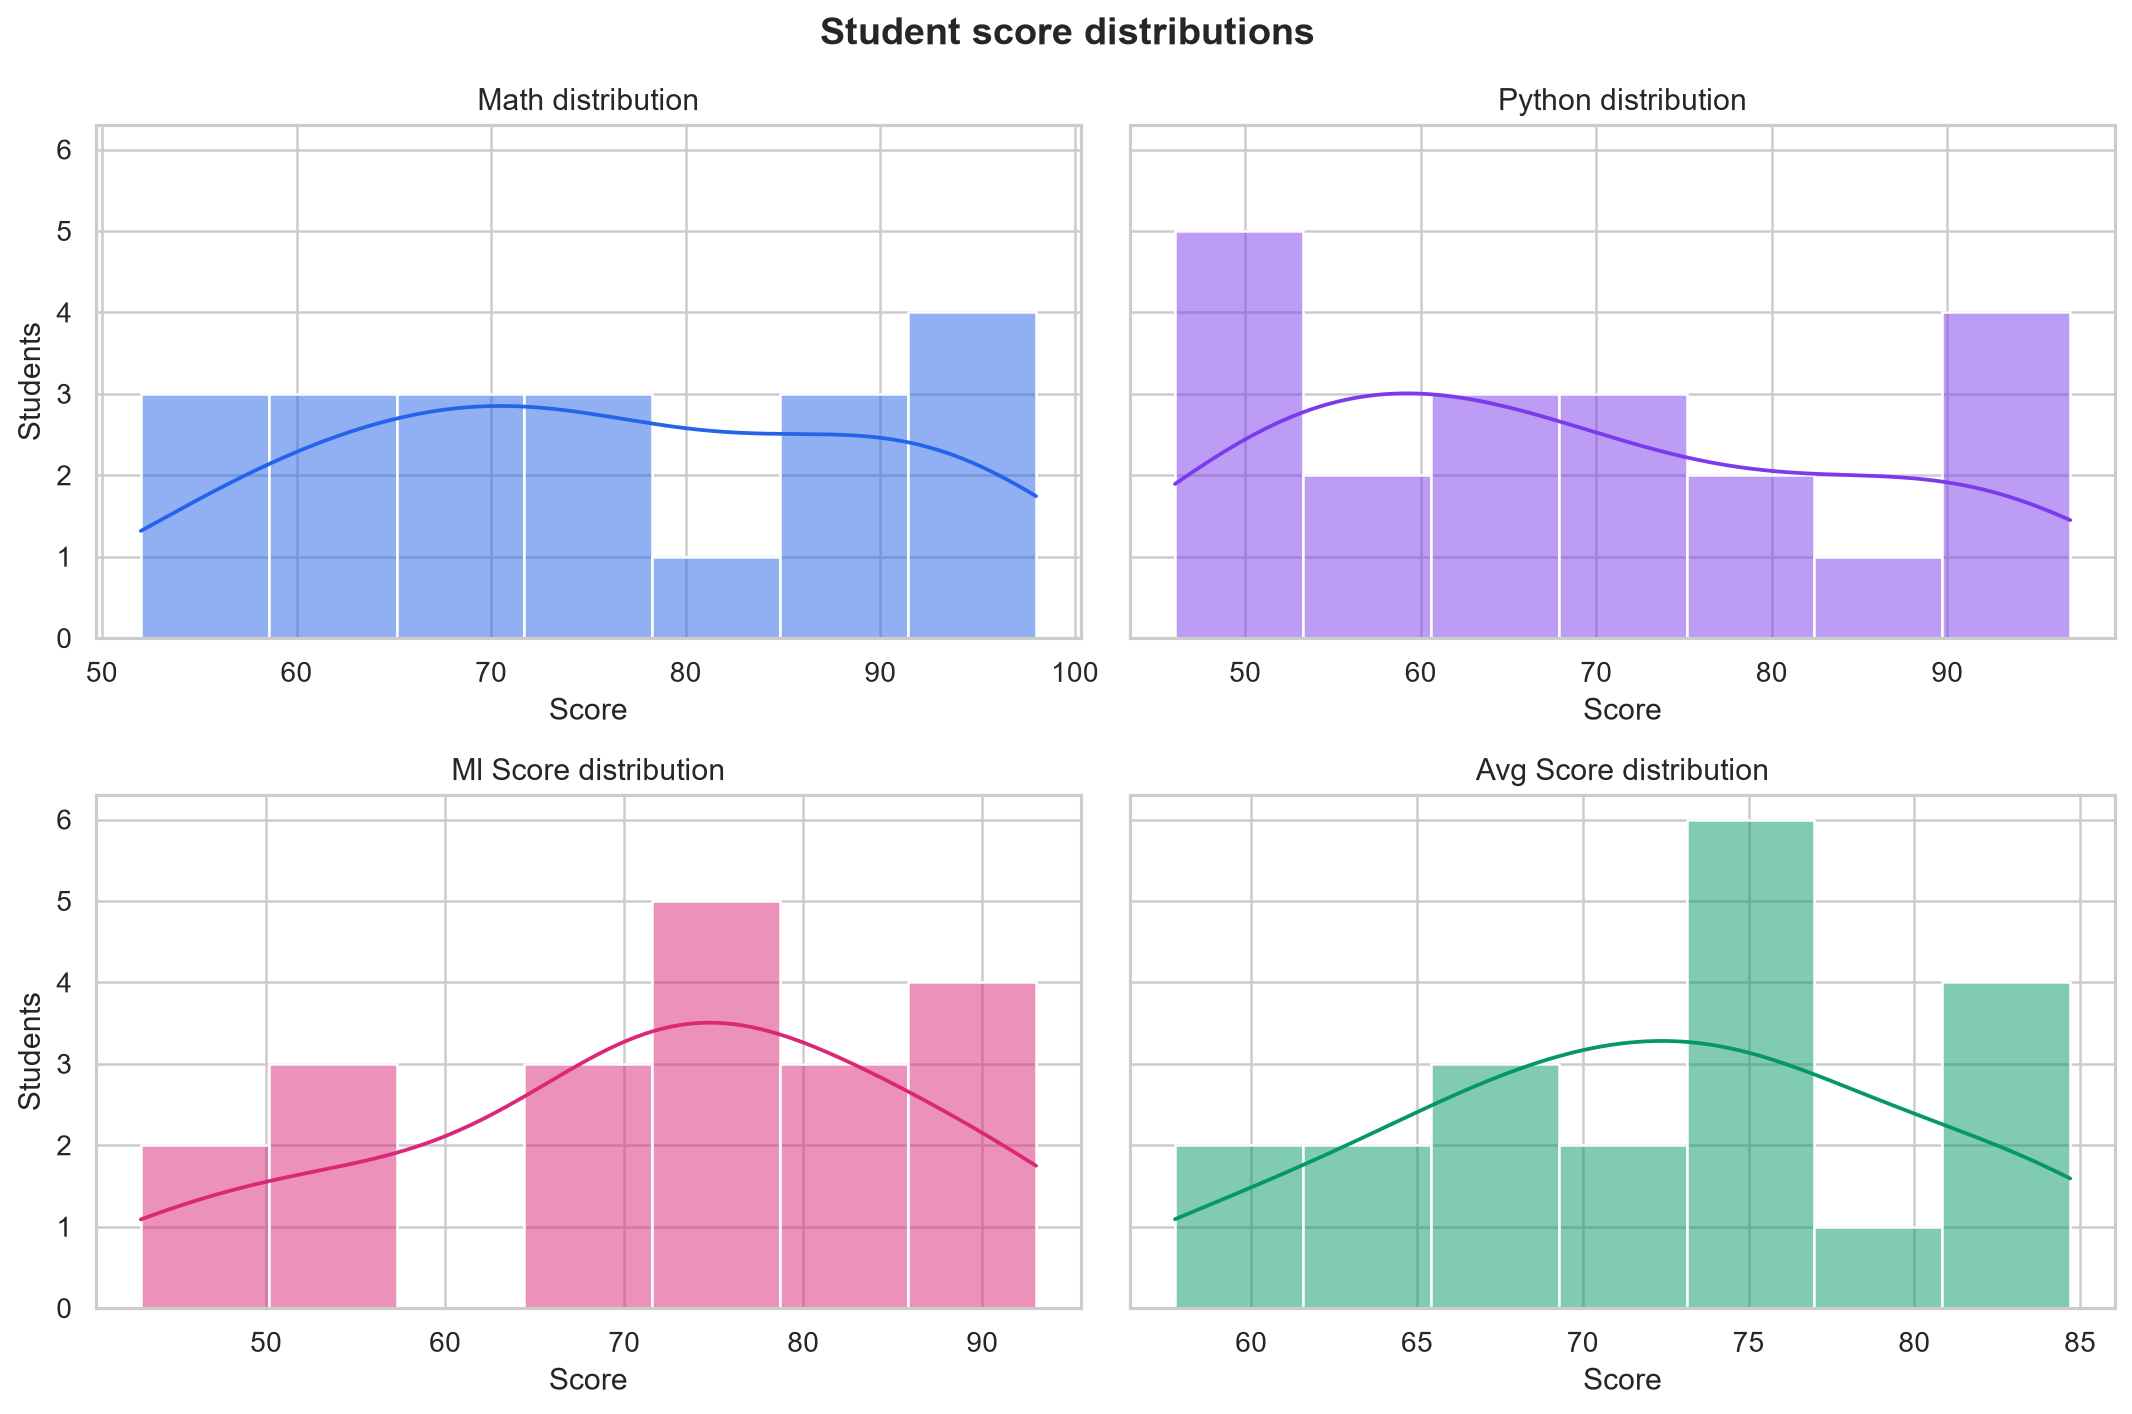

score_relationship.png


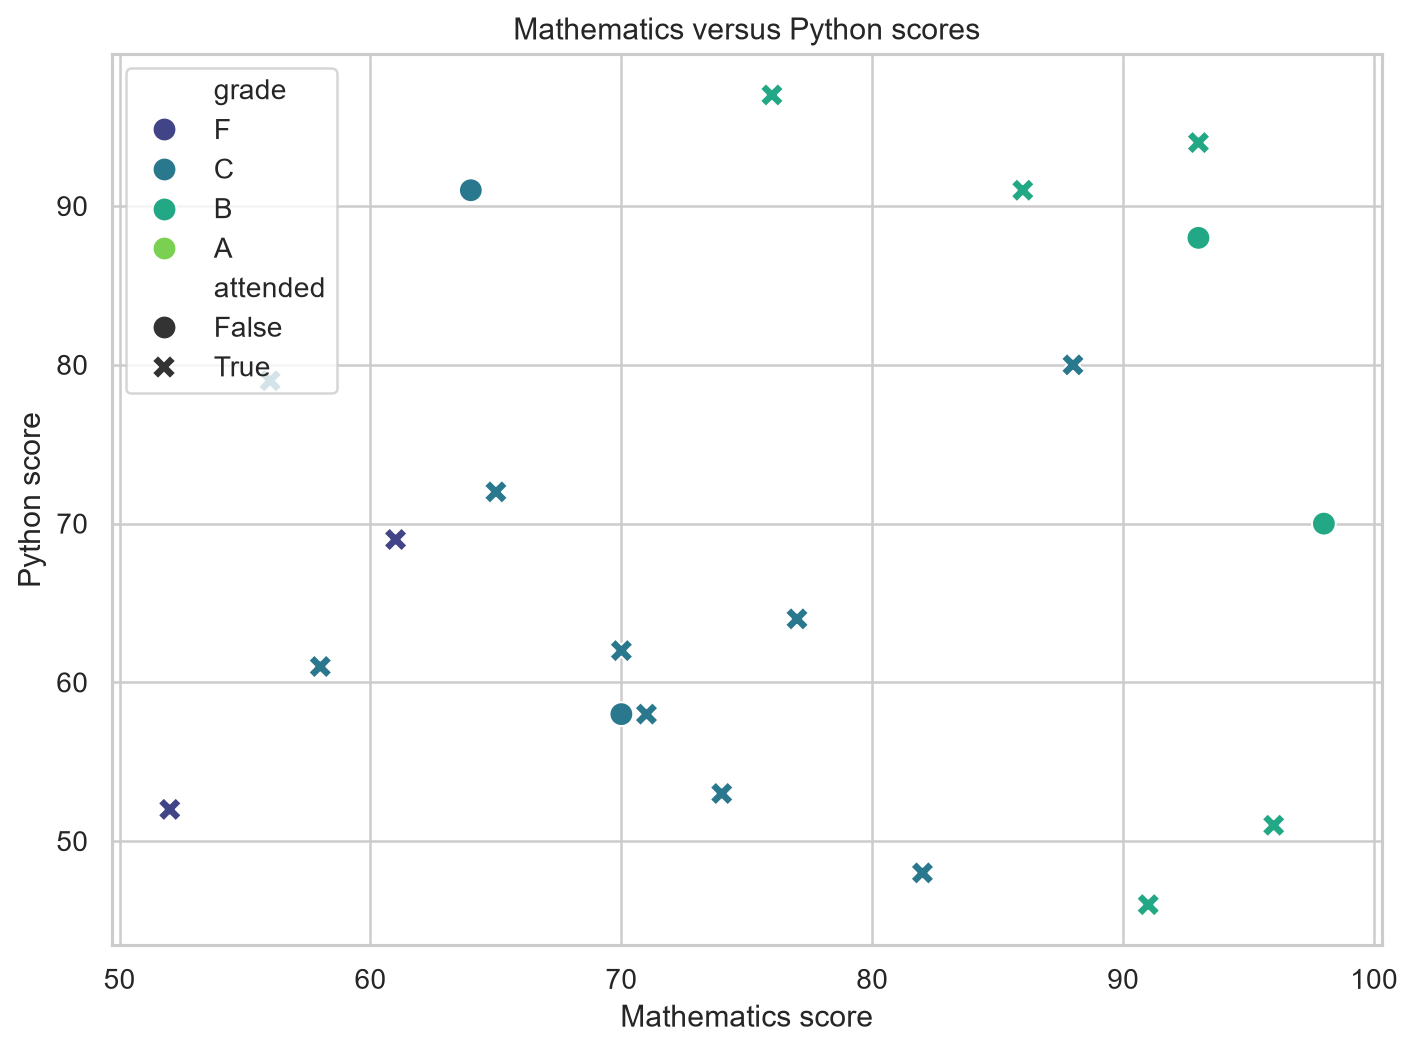

correlation_heatmap.png


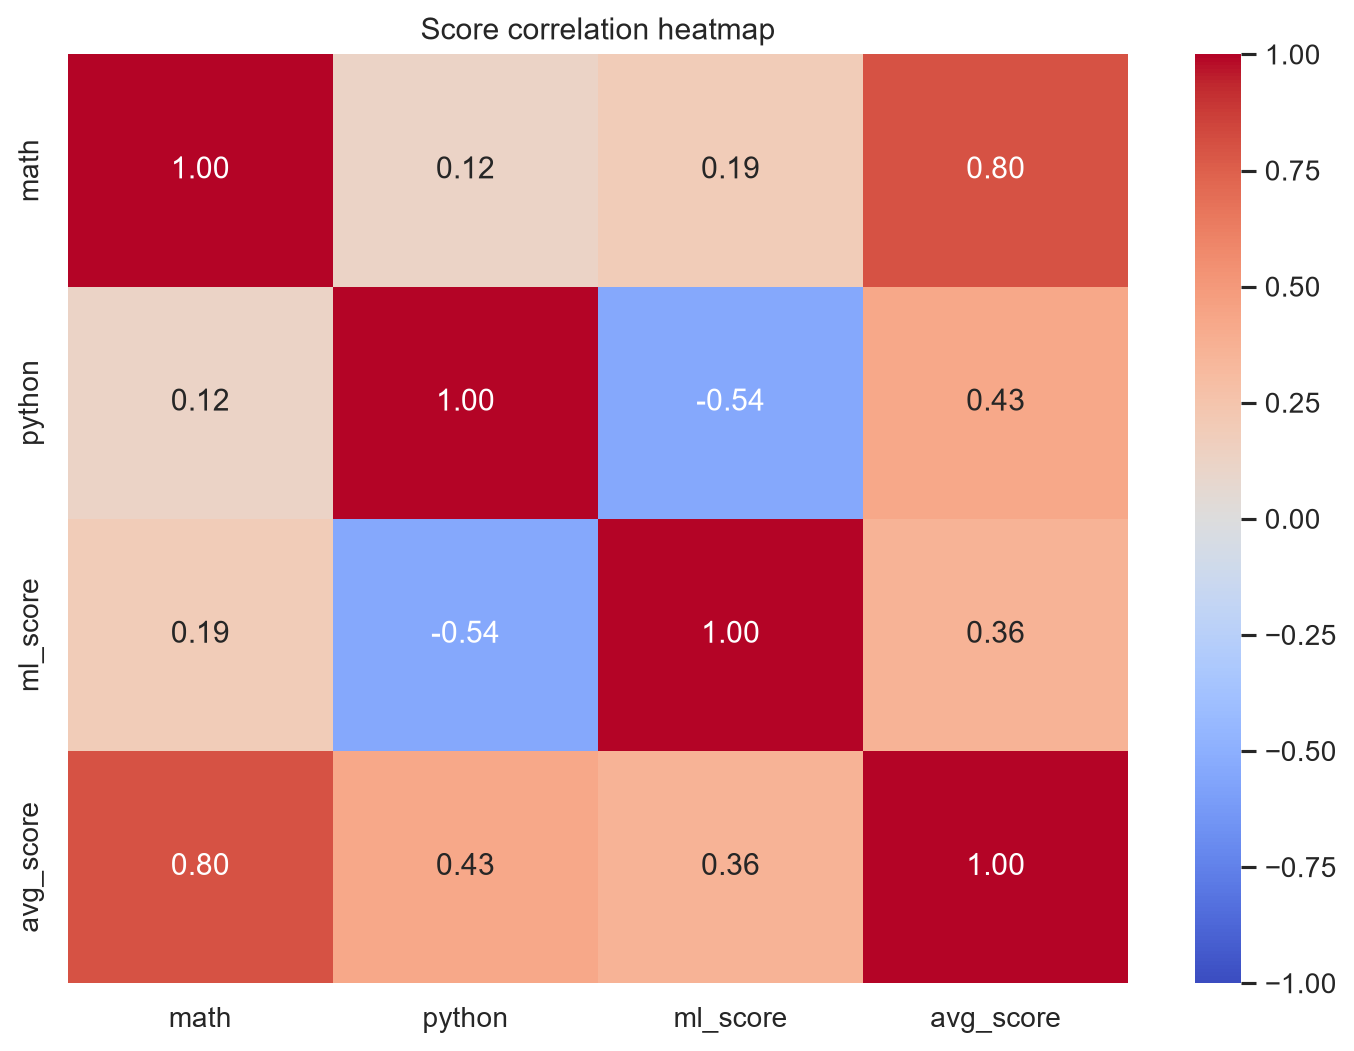

category_counts.png


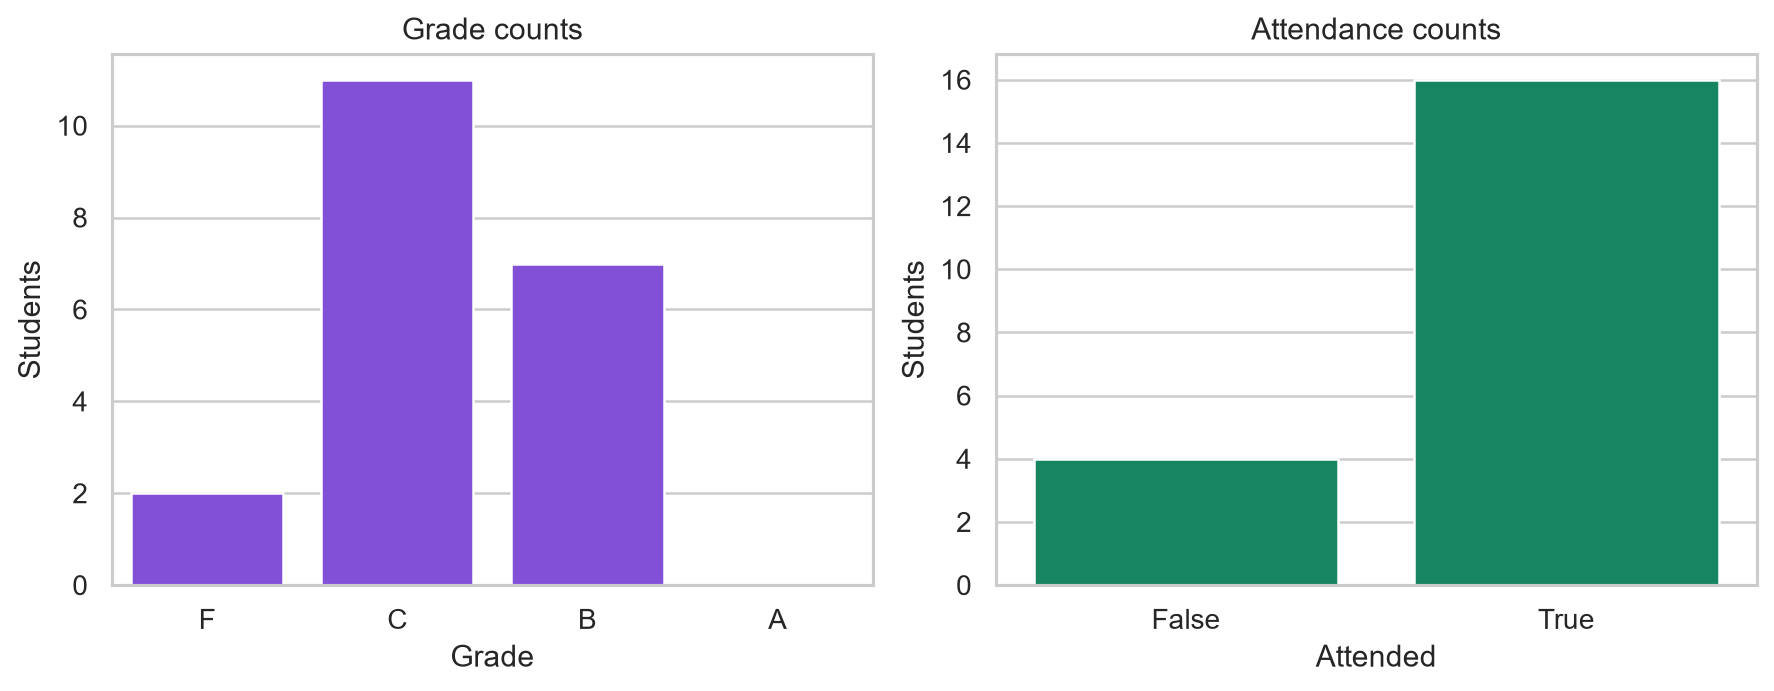

In [3]:
chart_paths = create_visualizations(df)
for path in chart_paths:
    print(path.name)
    display(Image(filename=str(path)))

## Visual findings

- Histograms show the distribution of every score feature, including the engineered average.
- The scatter plot compares Mathematics and Python performance while encoding grade and attendance.
- The heatmap highlights associations among source scores; `avg_score` is intentionally omitted because it is derived from those same scores.
- Category counts show the C/B-heavy grade distribution and the attendance-group imbalance.

The attendance group is much smaller for non-attendees, so visual differences should not be treated as causal conclusions.